# Description:

- Create CSV and accompanying plots of appointments for a given scenario

- First of all calculate appointments required by each staff type & appointment mode
{delivered, missed, unmet demand}

- Total demand = Sum{delivered, missed, unmet demand}

- FTE Calculations are in the repo.

Per month/Per alliance

##### Exam question/Objective:
Need the appointments for each of the healthcare staff mentioned.

For each demand scenario

For each capacity scenario

As we will be doing multiple ‘runs’ per scenario we will need mean, median columns. Consider other useful metrics to report confidence.

##### Key Data Sources:
Output from simulation
This is a very large dictionary
Consider writing a function to break it down.

##### Methodology/Approach:
Using the met demand + unmet demand, determine how much FTE is required.

##### Subtasks:
Wrangle data from simulation output

##### Outputs:
Github branch
CSV
forecast yaml file, run for all regression models

## Library Imports

In [1]:
import os
from pathlib import Path
if 'notebooks' in str(Path.cwd()):
    os.chdir('..')

# Library imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from matplotlib.ticker import FuncFormatter
import datetime as dt
import pickle
from typing import Dict
from time import sleep

# project imports from src
from src.schemas import DataCatalog
from src.various_methods import PlotCounter, get_workingdays
from src import constants

# Importing SNEE styles
from sneeifstyles import mpl_style
mpl_style()

import warnings
warnings.filterwarnings("ignore")

## Initial Set-up

In [58]:
## Constants
SNEE_SUB_ICB = ['06L','06T','07K']
SNEE_SUB_ICB_NAMES = ['Ipswich & East Suffolk', 'North East Essex', 'West Suffolk']
NOTEBOOK_ALIAS = "Appointments"
GP_PATIENTS_LIST_CATALOG = 'Patients Registered at a GP practice, September 2024'
ONS_POPULATION_CATALOG = 'ONS Population projections'
GP_APPOINTMENTS_CATALOG_NAME:str = 'Appointments in General Practice, August 2024'
GP_LIST_AGE_BANDS = constants.GP_LIST_AGE_BANDS 
GP_LIST_AGE_LABELS = constants.GP_LIST_AGE_LABELS 
SNEE_SUBICB_CODES = list(constants.ONS_CODES.keys())

# Loading the Data Catalog
catalog =  DataCatalog.load_from_yaml("data_catalog.yaml")

# Initializing the plotCounter object
plot_counter = PlotCounter(name=NOTEBOOK_ALIAS)

# set up output directories
for i in ['outputs/assumptions', 'outputs/plots', 'outputs/tables']:
    if not os.path.exists(i):
        os.makedirs(i)     

## 1. Loading the GP LIST

In [3]:
gp_list_df = catalog.get_catalog_entry_by_name(GP_PATIENTS_LIST_CATALOG)
patients_df = gp_list_df.load()
patients_df.head()

,PUBLICATION,EXTRACT_DATE,ORG_TYPE,ORG_CODE,ONS_CODE,POSTCODE,SEX,AGE_GROUP_5,NUMBER_OF_PATIENTS
0,GP_PRAC_PAT_LIST,2024-09-01,Comm Region,Y56,E40000003,NaN,ALL,ALL,11051350
1,GP_PRAC_PAT_LIST,2024-09-01,Comm Region,Y56,E40000003,NaN,FEMALE,0_4,255861
2,GP_PRAC_PAT_LIST,2024-09-01,Comm Region,Y56,E40000003,NaN,FEMALE,10_14,300274
3,GP_PRAC_PAT_LIST,2024-09-01,Comm Region,Y56,E40000003,NaN,FEMALE,15_19,295834
4,GP_PRAC_PAT_LIST,2024-09-01,Comm Region,Y56,E40000003,NaN,FEMALE,20_24,384423


### 1.1. Data Processing

- Renames age bands and columns to match ONS projections
- Removing 'all ages' rows
- Dropping unused columns
- Add column with 5 year age banding
- Filter to only SNEE ICB areas
- Group by sum on 5 year age group

In [4]:
#Replacing AGE_BANDS values to match the ONS_projection data
def rename_gp_list_age_bands_and_columns(df):
    """
    Renames age bands and columns in the given DataFrame to match ONS projections.
    Args:
        df (pandas.DataFrame): The DataFrame containing the data to be processed.
    Returns:
        pandas.DataFrame: A copy of the input DataFrame with the age bands and columns renamed.
    """
    df_ = df.copy()
    # replace these specific cases
    df_['AGE_GROUP_5'] = df_['AGE_GROUP_5'].replace({'90_94':'90+', '95+':'90+'})
    # change _ to - for consistency with ONS projections
    df_['AGE_GROUP_5'] = df_['AGE_GROUP_5'].str.replace('_','-')
    #Renaming the column name to match with ONS projection data
    df_ = df_.rename(columns={'ONS_CODE':'AREA_CODE'})
    return df_
    
    
def filter_gp_list_and_drop_unused_columns(df):
    """
    Filters the given DataFrame by dropping unused columns and rows corresponding to 'ALL' for AGE_GROUP_5. 
    Args:
        df (pandas.DataFrame): The input DataFrame to be filtered. 
    Returns:
        pandas.DataFrame: The filtered DataFrame with dropped columns and rows.
    """
    df_ = df.copy()
    # Dropping unused columns and rows corresponding to 'ALL' for AGE_GROUP_5 
    df_ = df_.loc[df_['AGE_GROUP_5']!='ALL']
    # This is due to the 'ALL' row being a sum of all the other rows, the 'SEX' == ALL rows are also dropped
    df_ = df_.drop(columns=['PUBLICATION','EXTRACT_DATE','ORG_TYPE','POSTCODE','SEX','ORG_CODE'])
    return df_


def filter_snee_icb_areas(df):
    """
    Filters the given DataFrame based on the 'ORG_CODE' column, keeping only the rows
    where the 'ORG_CODE' is in the list of SNEE_SUBICB_CODES.
    Args:
        df (pandas.DataFrame): The DataFrame to be filtered.
    Returns:
        pandas.DataFrame: The filtered DataFrame.
    """
    df_ = df.copy()
    df_ = df_.loc[df_['AREA_CODE'].isin(SNEE_SUBICB_CODES)]
    return df_


def groupbysum_area_and_age_group_and_rename_ons_codes(df):
    """
    Groups the DataFrame by AREA_CODE and AGE_GROUP_5, sums the values, drops the AGE_GROUP column if present,
    and renames the index using ONS_CODES.
    Args:
        df (pandas.DataFrame): The input DataFrame.
    Returns:
        pandas.DataFrame: The modified DataFrame with grouped, summed, and renamed values.
    """
    df_ = df.copy()
    # Grouping by AREA_CODE and AGE_GROUP_5 and summing the values
    df_ = df_.groupby(['AREA_CODE','AGE_GROUP_5'], observed=False).sum()
    # Renaming ONS codes with Actual sub icb names
    df_ = df_.rename(index=constants.ONS_CODES)
    return df_

patients_df = (patients_df
                .pipe(rename_gp_list_age_bands_and_columns)
                .pipe(filter_gp_list_and_drop_unused_columns)
                .pipe(filter_snee_icb_areas)
                .pipe(groupbysum_area_and_age_group_and_rename_ons_codes))

patients_df.head()

NUMBER_OF_PATIENTS
AREA_CODE              AGE_GROUP_5                    
Ipswich & East Suffolk 0-4                       17916
                       10-14                     24285
                       15-19                     24206
                       20-24                     19972
                       25-29                     22902

In [5]:
# Transposing the dataframe
patients_df_transformed = (patients_df.T).stack(level='AREA_CODE').reset_index()
patients_df_transformed = patients_df_transformed.drop(columns = ['level_0'])
patients_df_transformed.columns.name = None
patients_df_transformed

,AREA_CODE,0-4,10-14,15-19,20-24,25-29,30-34,35-39,40-44,45-49,5-9,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85-89,90+
0,Ipswich & East Suffolk,17916,24285,24206,19972,22902,26221,27633,26900,24855,21883,27644,29238,28203,24598,22245,21906,13725,8680,5001
1,North East Essex,17157,22233,20284,21635,24086,25674,25041,23187,21337,20395,23223,24945,23766,20572,19178,20181,12611,7486,4229
2,West Suffolk,12253,15571,14965,12841,15341,17696,18210,17584,16356,14182,18652,20623,19385,16073,15151,15560,10047,5913,3093


## 2. ONS Population projections

### 2.1. Data loading & processing
- Removing 'all ages' rows
- removing columns prior to 2024
- removing 'AREA NAME' 'COMPONENT' and 'SEX' column
- Add column with 5 year age banding
- Filter to only SNEE ICB areas
- Group by sum on 5 year age group

In [6]:
# Loading the Principal projection
# ons_principal_projection = catalog.get_scenario_catalog_entry_by_name(ONS_POPULATION_CATALOG,'Principal projection')
# principal_projections_df = ons_principal_projection.load()

# # Loading the 10 year migration Projections
# ons_10_mig_projection = catalog.get_scenario_catalog_entry_by_name(ONS_POPULATION_CATALOG,'10 year migration variant')
# mig_10yr_projections_df = ons_10_mig_projection.load()

# # Loading the High international migration Projections
# ons_high_mig_projection = catalog.get_scenario_catalog_entry_by_name(ONS_POPULATION_CATALOG,'High international migration variant')
# high_mig_projections_df = ons_high_mig_projection.load()

# # Loading the Low international migration Projections
# ons_low_mig_projection = catalog.get_scenario_catalog_entry_by_name(ONS_POPULATION_CATALOG,'Low international migration variant')
# low_mig_projections_df = ons_low_mig_projection.load()

# # Loading the Alternative internal migration Projections
# ons_alt_mig_projection = catalog.get_scenario_catalog_entry_by_name(ONS_POPULATION_CATALOG,'Alternative internal migration variant')
# alt_mig_projections_df = ons_alt_mig_projection.load()

In [7]:
def drop_all_ages_and_unused_cols(df) -> pd.DataFrame:
    """
    Rename columns in the DataFrame and drop unused columns.
    Parameters:
    df (pd.DataFrame): The input DataFrame.
    Returns:
    pd.DataFrame: The modified DataFrame with renamed and dropped columns.
    """
    df_ = df.copy()
    df_ = df_.loc[df_['AGE_GROUP'] != 'All ages']
    df_ = df_.drop(columns=['AREA_NAME', 'COMPONENT', 'SEX', '2018', '2019', '2020', '2021', '2022','2023'])
    return df_


def convert_ons_projection_to_5yr_bins(df):
    """
    Convert the ONS projection data to 5-year age bands.
    Args:
        df (pandas.DataFrame): The input DataFrame containing the ONS projection data.
    Returns:
        pandas.DataFrame: The DataFrame with the ONS projection data converted to 5-year age bands.
    """
    df_ = df.copy()
    # replace the text '90 and over' with '90' to match the GP list data
    df_['AGE_GROUP'] = df_['AGE_GROUP'].astype(str).str.replace('90 and over','90')
    #Converting AGE_GROUP data type to int
    df_['AGE_GROUP'] = df_['AGE_GROUP'].astype(int)
    #Adding the column for Age Bands as 'AGE_GROUP_5'
    df_['AGE_GROUP_5'] = pd.cut(df_['AGE_GROUP'], bins=GP_LIST_AGE_BANDS, labels=GP_LIST_AGE_LABELS, include_lowest=True, right=False, ordered=True)
    # Dropping the original age column
    df_ = df_.drop(columns=['AGE_GROUP'], errors='ignore')
    return df_


def groupbysum_area_and_age_group_and_rename_ons_codes(df):
    """
    Groups the DataFrame by AREA_CODE and AGE_GROUP_5, sums the values, drops the AGE_GROUP column if present,
    and renames the index using ONS_CODES.
    Args:
        df (pandas.DataFrame): The input DataFrame.
    Returns:
        pandas.DataFrame: The modified DataFrame with grouped, summed, and renamed values.
    """
    df_ = df.copy()
    # Grouping by AREA_CODE and AGE_GROUP_5 and summing the values
    df_ = df_.groupby(['AREA_CODE','AGE_GROUP_5'], observed=False).sum()
    # Renaming ONS codes with Actual sub icb names
    df_ = df_.rename(index=constants.ONS_CODES)
    return df_


# create a dict containing the projections for each scenario in the ONS projections
ons_projections:Dict[str,pd.DataFrame] = {}

for scenario_entry in catalog.get_top_level_scenario_by_name('ONS Population projections').scenarios:
    print("Collecting & Processing: ", scenario_entry.name)
    scenario_name = scenario_entry.name
    scenario_df = (scenario_entry.load()
                    .pipe(drop_all_ages_and_unused_cols)
                    .pipe(convert_ons_projection_to_5yr_bins)
                    .pipe(filter_snee_icb_areas)
                    .pipe(groupbysum_area_and_age_group_and_rename_ons_codes)
    )
    ons_projections[scenario_entry.name] = scenario_df
    sleep(10) #  ons seems to mbe blocking us, so we sleep for 10 second

ons_projections['Principal projection'].head()

2024       2025       2026  \
AREA_CODE              AGE_GROUP_5                                    
Ipswich & East Suffolk 0-4          19698.373  19604.966  19527.257   
                       5-9          22378.224  21998.493  21529.082   
                       10-14        25016.257  24783.209  24569.717   
                       15-19        23496.655  23897.784  24193.275   
                       20-24        17173.888  17191.096  17520.013   

                                         2027       2028       2029  \
AREA_CODE              AGE_GROUP_5                                    
Ipswich & East Suffolk 0-4          19483.805  19446.523  19414.341   
                       5-9          21261.284  21050.186  20983.672   
                       10-14        24249.751  24005.345  23584.788   
                       15-19        24317.998  24191.858  24085.124   
                       20-24        17987.881  18489.898  18808.913   

                                         2030       2031       2032  \
AREA_CODE              AGE_GROUP_5                                    
Ipswich & East Suffolk 0-4          19391.237  19381.836  19393.561   
                       5-9          20896.032  20825.220  20787.879   
                       10-14        23208.398  22734.049  22463.455   
                       15-19        23861.980  23735.101  23447.633   
                       20-24        19207.344  19504.800  19722.030   

                                         2033       2034       2035  \
AREA_CODE              AGE_GROUP_5                                    
Ipswich & East Suffolk 0-4          19429.657  19490.582  19575.604   
                       5-9          20756.586  20730.435  20713.191   
                       10-14        22247.084  22183.313  22097.687   
                       15-19        23183.517  22773.296  22376.525   
                       20-24        19737.583  19789.355  19742.953   

                                         2036       2037       2038  \
AREA_CODE              AGE_GROUP_5                                    
Ipswich & East Suffolk 0-4          19686.005  19821.500  19978.838   
                       5-9          20709.948  20728.187  20771.506   
                       10-14        22028.982  21994.096  21965.440   
                       15-19        21998.140  21733.338  21566.061   
                       20-24        19656.351  19404.588  19195.243   

                                         2039       2040       2041  \
AREA_CODE              AGE_GROUP_5                                    
Ipswich & East Suffolk 0-4          20152.670  20332.876  20507.740   
                       5-9          20840.531  20934.368  21054.439   
                       10-14        21942.197  21928.291  21928.799   
                       15-19        21499.806  21422.362  21367.768   
                       20-24        18928.754  18660.077  18324.626   

                                         2042       2043  
AREA_CODE              AGE_GROUP_5                        
Ipswich & East Suffolk 0-4          20666.628  20800.504  
                       5-9          21200.433  21369.098  
                       10-14        21951.560  22000.292  
                       15-19        21336.679  21311.481  
                       20-24        18080.678  17917.411

### 2.2. Calculating the population change factor for each year and tranposing the dataframe
- 2024 as baseline

In [29]:
def calculate_population_change_factor(df):
    """
    Calculates the population change factor by keeping 2024 population as baseline and dividing all years population by the baseline
    Args:
        df (pandas.DataFrame): The input DataFrame.
    Returns:
        pandas.DataFrame: The modified DataFrame with population change factors for each year
    """
    df_ = df.copy()
    # create a baseline (series/1 column)
    pop_baseline:pd.Series = df_['2024']
    # divide the projections by the baseline to get the relative factors
    df_:pd.DataFrame = df_.div(pop_baseline, axis=0).round(5)
    return df_


def transpose_dataframe(df):
    df_ = df.copy()
    # TRansposing the dataframe
    df_ = (df_.T).stack(level='AREA_CODE').reset_index().rename(columns={'level_0': 'DATE'})
    df_.columns.name = None
    df_ = df_.sort_values(by=['AREA_CODE', 'DATE']).reset_index(drop=True)
    # Adding month and date in the DATE column
    df_['DATE'] = df_['DATE'].str.zfill(4) + '-09-01'
    # Converting DATE back to datetime
    df_['DATE'] = pd.to_datetime(df_['DATE'])
    return df_
    
transformed_projections = {}


for scenario_name, df in ons_projections.items():
    # Apply the pipeline to each DataFrame and store the result in `transformed_projections`
    transformed_projections[scenario_name] = (
        df.pipe(calculate_population_change_factor)
          .pipe(transpose_dataframe)
    )
 
transformed_projections['Principal projection'].head()

,DATE,AREA_CODE,0-4,5-9,10-14,15-19,20-24,25-29,30-34,35-39,...,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85-89,90+
0,2024-09-01,Ipswich & East Suffolk,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,...,1.00000,1.00000,1.00000,1.00000,1.0000,1.00000,1.00000,1.00000,1.00000,1.00000
1,2025-09-01,Ipswich & East Suffolk,0.99526,0.98303,0.99068,1.01707,1.00100,0.98387,0.99131,1.00265,...,1.01413,0.96956,0.99293,1.03106,1.0204,0.99384,1.01966,1.05365,1.01015,1.03269
2,2026-09-01,Ipswich & East Suffolk,0.99131,0.96205,0.98215,1.02965,1.02015,0.96232,0.97853,1.00799,...,1.03579,0.92896,0.99006,1.04575,1.0540,0.99569,1.02749,1.12172,1.01096,1.05683
3,2027-09-01,Ipswich & East Suffolk,0.98911,0.95009,0.96936,1.03496,1.04740,0.93405,0.97215,1.00579,...,1.06271,0.89626,0.97767,1.06185,1.0723,1.01661,0.97600,1.25321,1.04241,1.08529
4,2028-09-01,Ipswich & East Suffolk,0.98721,0.94065,0.95959,1.02959,1.07663,0.91783,0.96578,0.99540,...,1.08015,0.86974,0.96606,1.06365,1.0975,1.04052,0.95357,1.32208,1.08616,1.12230


### 2.3. Making synthetic data using interpolation

In [18]:
ons_principal_projection = catalog.get_scenario_catalog_entry_by_name(ONS_POPULATION_CATALOG,'Principal projection')
principal_projections_df = ons_principal_projection.load()

date_range_df = pd.DataFrame(pd.date_range(start=dt.date(year=int(principal_projections_df.T.index[11]),month=9,day=1), end=dt.date(year=int(principal_projections_df.T.index[-1]),month=9,day=1), freq='MS')).rename(columns={0:'DATE'})
date_range_df = date_range_df.loc[date_range_df.index.repeat(3)]
date_range_df['AREA_CODE'] = SNEE_SUB_ICB_NAMES * (len(date_range_df) // len(SNEE_SUB_ICB_NAMES))

date_range_df

,DATE,AREA_CODE
0,2024-09-01,Ipswich & East Suffolk
0,2024-09-01,North East Essex
0,2024-09-01,West Suffolk
1,2024-10-01,Ipswich & East Suffolk
1,2024-10-01,North East Essex
...,...,...
227,2043-08-01,North East Essex
227,2043-08-01,West Suffolk
228,2043-09-01,Ipswich & East Suffolk
228,2043-09-01,North East Essex


In [30]:
projections_interpolated = {}

for scenario_name, df in transformed_projections.items():
    projections_interpolated[scenario_name] = pd.merge(date_range_df, df, on=('DATE','AREA_CODE'), how='left')
    projections_interpolated[scenario_name] = projections_interpolated[scenario_name].sort_values(by=['AREA_CODE', 'DATE']).reset_index(drop=True)
    projections_interpolated[scenario_name] = projections_interpolated[scenario_name].interpolate(method='linear')
    projections_interpolated[scenario_name] = projections_interpolated[scenario_name].set_index(['AREA_CODE','DATE'])

projections_interpolated['Principal projection'].head()

0-4       5-9     10-14     15-19  \
AREA_CODE              DATE                                                 
Ipswich & East Suffolk 2024-09-01  1.000000  1.000000  1.000000  1.000000   
                       2024-10-01  0.999605  0.998586  0.999223  1.001422   
                       2024-11-01  0.999210  0.997172  0.998447  1.002845   
                       2024-12-01  0.998815  0.995757  0.997670  1.004268   
                       2025-01-01  0.998420  0.994343  0.996893  1.005690   

                                      20-24     25-29     30-34     35-39  \
AREA_CODE              DATE                                                 
Ipswich & East Suffolk 2024-09-01  1.000000  1.000000  1.000000  1.000000   
                       2024-10-01  1.000083  0.998656  0.999276  1.000221   
                       2024-11-01  1.000167  0.997312  0.998552  1.000442   
                       2024-12-01  1.000250  0.995968  0.997827  1.000663   
                       2025-01-01  1.000333  0.994623  0.997103  1.000883   

                                      40-44     45-49     50-54     55-59  \
AREA_CODE              DATE                                                 
Ipswich & East Suffolk 2024-09-01  1.000000  1.000000  1.000000  1.000000   
                       2024-10-01  1.000042  1.001178  0.997463  0.999411   
                       2024-11-01  1.000085  1.002355  0.994927  0.998822   
                       2024-12-01  1.000128  1.003532  0.992390  0.998232   
                       2025-01-01  1.000170  1.004710  0.989853  0.997643   

                                      60-64   65-69     70-74     75-79  \
AREA_CODE              DATE                                               
Ipswich & East Suffolk 2024-09-01  1.000000  1.0000  1.000000  1.000000   
                       2024-10-01  1.002588  1.0017  0.999487  1.001638   
                       2024-11-01  1.005177  1.0034  0.998973  1.003277   
                       2024-12-01  1.007765  1.0051  0.998460  1.004915   
                       2025-01-01  1.010353  1.0068  0.997947  1.006553   

                                      80-84     85-89       90+  
AREA_CODE              DATE                                      
Ipswich & East Suffolk 2024-09-01  1.000000  1.000000  1.000000  
                       2024-10-01  1.004471  1.000846  1.002724  
                       2024-11-01  1.008942  1.001692  1.005448  
                       2024-12-01  1.013413  1.002538  1.008173  
                       2025-01-01  1.017883  1.003383  1.010897

## 2.4. Multiplying change factors by population from GP list (09/2024)

In [31]:
for scenario_name, df in projections_interpolated.items():
    df.loc[:,GP_LIST_AGE_LABELS] = (df.loc[:,GP_LIST_AGE_LABELS] * patients_df_transformed.set_index('AREA_CODE')).round(2)
    df['Total Population'] = df.sum(axis=1)
    # Divide all columns by 'Total Population' except 'Total Population' itself
    df.loc[:, df.columns != 'Total Population'] = df.loc[:, df.columns != 'Total Population'].div(df['Total Population'], axis=0)
    df = df.reset_index()
    df['month'] = df['DATE'].dt.month
    # Set 'AREA_CODE', 'DATE', and 'Total Population' as a multi-index
    df = df.set_index(['AREA_CODE', 'DATE', 'Total Population'])
    # Save the modified DataFrame back to the dictionary
    projections_interpolated[scenario_name] = df
    
projections_interpolated['Principal projection'].head()

0-4       5-9  \
AREA_CODE              DATE       Total Population                       
Ipswich & East Suffolk 2024-09-01 418013.00         0.042860  0.052350   
                       2024-10-01 418113.20         0.042833  0.052263   
                       2024-11-01 418213.43         0.042806  0.052177   
                       2024-12-01 418313.66         0.042778  0.052090   
                       2025-01-01 418413.88         0.042751  0.052004   

                                                       10-14     15-19  \
AREA_CODE              DATE       Total Population                       
Ipswich & East Suffolk 2024-09-01 418013.00         0.058096  0.057907   
                       2024-10-01 418113.20         0.058037  0.057976   
                       2024-11-01 418213.43         0.057978  0.058044   
                       2024-12-01 418313.66         0.057919  0.058113   
                       2025-01-01 418413.88         0.057860  0.058181   

                                                       20-24     25-29  \
AREA_CODE              DATE       Total Population                       
Ipswich & East Suffolk 2024-09-01 418013.00         0.047778  0.054788   
                       2024-10-01 418113.20         0.047771  0.054701   
                       2024-11-01 418213.43         0.047763  0.054614   
                       2024-12-01 418313.66         0.047756  0.054528   
                       2025-01-01 418413.88         0.047749  0.054441   

                                                       30-34     35-39  \
AREA_CODE              DATE       Total Population                       
Ipswich & East Suffolk 2024-09-01 418013.00         0.062728  0.066106   
                       2024-10-01 418113.20         0.062667  0.066104   
                       2024-11-01 418213.43         0.062607  0.066103   
                       2024-12-01 418313.66         0.062546  0.066102   
                       2025-01-01 418413.88         0.062486  0.066101   

                                                       40-44     45-49  \
AREA_CODE              DATE       Total Population                       
Ipswich & East Suffolk 2024-09-01 418013.00         0.064352  0.059460   
                       2024-10-01 418113.20         0.064339  0.059516   
                       2024-11-01 418213.43         0.064327  0.059571   
                       2024-12-01 418313.66         0.064314  0.059627   
                       2025-01-01 418413.88         0.064301  0.059683   

                                                       50-54     55-59  \
AREA_CODE              DATE       Total Population                       
Ipswich & East Suffolk 2024-09-01 418013.00         0.066132  0.069945   
                       2024-10-01 418113.20         0.065948  0.069887   
                       2024-11-01 418213.43         0.065765  0.069829   
                       2024-12-01 418313.66         0.065581  0.069771   
                       2025-01-01 418413.88         0.065398  0.069714   

                                                       60-64     65-69  \
AREA_CODE              DATE       Total Population                       
Ipswich & East Suffolk 2024-09-01 418013.00         0.067469  0.058845   
                       2024-10-01 418113.20         0.067628  0.058931   
                       2024-11-01 418213.43         0.067786  0.059017   
                       2024-12-01 418313.66         0.067944  0.059103   
                       2025-01-01 418413.88         0.068102  0.059188   

                                                       70-74     75-79  \
AREA_CODE              DATE       Total Population                       
Ipswich & East Suffolk 2024-09-01 418013.00         0.053216  0.052405   
                       2024-10-01 418113.20         0.053176  0.052478   
                       2024-11-01 418213.43         0.053136  0.052552   
                       2024-12-01 418313.66         0.

## 3. Modelling

### 3.1. Loading the model

In [32]:
# Load the model from the .pkl file
with open('outputs/demographic-month-sklearn.pkl', 'rb') as file:  # Use the correct path to your .pkl file
    model = pickle.load(file)
    
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('sin_cos',
                                                  FunctionTransformer(func=<function sin_cos_transformer at 0x74035b0afc40>),
                                                  ['month']),
                                                 ('pca', PCA(n_components=4),
                                                  ['0-4', '10-14', '15-19',
                                                   '20-24', '25-29', '30-34',
                                                   '35-39', '40-44', '5-9',
                                                   '50-54', '55-59', '60-64',
                                                   '65-69', '70-74', '75-79',
                                                   '80-84', '85-89',
                                                   '90+'])])),
                ('model', Ridge(alpha=0.1))])

### 3.2. Making predictions and calculating "Predicted appointments per month"

In [33]:
projections_after_modelling = {}

for scenario_name, df in projections_interpolated.items():
    # Make predictions
    predictions = model.predict(df)

    # Add predictions (Appointments per person per working day) to the DataFrame
    df['Predictions'] = predictions
    
    # Calculate predictions (Appointments per working day)
    df['Predicted appointments per working day'] = (df.index.get_level_values('Total Population') * df['Predictions']).round(2)

    # Get working days/month
    df['working_days'] = get_workingdays(df.index.get_level_values('DATE').to_series().dt)

    # Calculate predictions (Appointments per month)
    df["Predicted appointments per month"] = (df['Predicted appointments per working day'] * df['working_days']).round(2)
    df = df.copy().reset_index().rename(columns={'AREA_CODE':'Sub-ICB'})

    # Save the modified DataFrame back to the dictionary
    projections_after_modelling[scenario_name] = df
    
projections_after_modelling['Principal projection'].head()

,Sub-ICB,DATE,Total Population,0-4,5-9,10-14,15-19,20-24,25-29,30-34,...,70-74,75-79,80-84,85-89,90+,month,Predictions,Predicted appointments per working day,working_days,Predicted appointments per month
0,Ipswich & East Suffolk,2024-09-01,418013.00,0.042860,0.052350,0.058096,0.057907,0.047778,0.054788,0.062728,...,0.053216,0.052405,0.032834,0.020765,0.011964,9,0.021780,9104.53,21,191195.13
1,Ipswich & East Suffolk,2024-10-01,418113.20,0.042833,0.052263,0.058037,0.057976,0.047771,0.054701,0.062667,...,0.053176,0.052478,0.032973,0.020777,0.011993,10,0.022332,9337.39,23,214759.97
2,Ipswich & East Suffolk,2024-11-01,418213.43,0.042806,0.052177,0.057978,0.058044,0.047763,0.054614,0.062607,...,0.053136,0.052552,0.033112,0.020790,0.012023,11,0.022624,9461.53,21,198692.13
3,Ipswich & East Suffolk,2024-12-01,418313.66,0.042778,0.052090,0.057919,0.058113,0.047756,0.054528,0.062546,...,0.053096,0.052625,0.033250,0.020803,0.012053,12,0.022581,9445.80,20,188916.00
4,Ipswich & East Suffolk,2025-01-01,418413.88,0.042751,0.052004,0.057860,0.058181,0.047749,0.054441,0.062486,...,0.053056,0.052698,0.033389,0.020815,0.012083,1,0.022218,9296.52,22,204523.44


## 4. Combining the predictions and population from all scenarios into a Dataframe

In [34]:
projections_combined_df = projections_after_modelling[list(projections_after_modelling.keys())[0]][['Sub-ICB', 'DATE']].copy()

for scenario_name, df in projections_after_modelling.items():
    required_columns = df[['Total Population', 'Predicted appointments per month']]
    
    # Rename these columns by adding the scenario_name as a prefix
    required_columns.rename(columns={
        'Total Population': f'Population ({scenario_name})',
        'Predicted appointments per month': f'Predicted appointments per month ({scenario_name})'
    }, inplace=True)
    
    # Concatenate the required columns with the main projections_combined_df
    projections_combined_df = pd.concat([projections_combined_df, required_columns], axis=1)
    
projections_combined_df.head()

,Sub-ICB,DATE,Population (Principal projection),Predicted appointments per month (Principal projection),Population (10 year migration variant),Predicted appointments per month (10 year migration variant),Population (High international migration variant),Predicted appointments per month (High international migration variant),Population (Low international migration variant),Predicted appointments per month (Low international migration variant),Population (Alternative internal migration variant),Predicted appointments per month (Alternative internal migration variant)
0,Ipswich & East Suffolk,2024-09-01,418013.00,191195.13,418013.00,191195.13,418013.00,191195.13,418013.00,191195.13,418013.00,191195.13
1,Ipswich & East Suffolk,2024-10-01,418113.20,214759.97,418124.75,214769.40,418155.70,214775.84,418070.19,214743.87,418115.63,214764.11
2,Ipswich & East Suffolk,2024-11-01,418213.43,198692.13,418236.51,198709.56,418298.41,198721.95,418127.41,198662.10,418218.26,198699.90
3,Ipswich & East Suffolk,2024-12-01,418313.66,188916.00,418348.28,188940.80,418441.12,188958.20,418184.61,188873.20,418320.86,188927.00
4,Ipswich & East Suffolk,2025-01-01,418413.88,204523.44,418460.06,204559.52,418583.83,204583.94,418241.83,204462.28,418423.48,204539.50


### 4.1. Smoothing the data using moving averages

In [119]:
# Apply a 12-month moving average to smooth out the 'Predicted appointments per month' columns
smoothed_df = projections_combined_df.copy()
for col in smoothed_df.columns:
    if 'Predicted appointments per month' in col:
        smoothed_df[col] = smoothed_df.groupby('Sub-ICB')[col].rolling(window=12, min_periods=12).mean().reset_index(level=0, drop=True)
smoothed_df.head()

,Sub-ICB,DATE,Population (Principal projection),Predicted appointments per month (Principal projection),Population (10 year migration variant),Predicted appointments per month (10 year migration variant),Population (High international migration variant),Predicted appointments per month (High international migration variant),Population (Low international migration variant),Predicted appointments per month (Low international migration variant),Population (Alternative internal migration variant),Predicted appointments per month (Alternative internal migration variant)
0,Ipswich & East Suffolk,2024-09-01,418013.00,NaN,418013.00,NaN,418013.00,NaN,418013.00,NaN,418013.00,NaN
1,Ipswich & East Suffolk,2024-10-01,418113.20,NaN,418124.75,NaN,418155.70,NaN,418070.19,NaN,418115.63,NaN
2,Ipswich & East Suffolk,2024-11-01,418213.43,NaN,418236.51,NaN,418298.41,NaN,418127.41,NaN,418218.26,NaN
3,Ipswich & East Suffolk,2024-12-01,418313.66,NaN,418348.28,NaN,418441.12,NaN,418184.61,NaN,418320.86,NaN
4,Ipswich & East Suffolk,2025-01-01,418413.88,NaN,418460.06,NaN,418583.83,NaN,418241.83,NaN,418423.48,NaN


### 4.3. Getting the original appointments from Appointments in General Practice

In [121]:
appointments_catalog_entry = catalog.get_catalog_entry_by_name(GP_APPOINTMENTS_CATALOG_NAME)
appointments_df = appointments_catalog_entry.load()

appointments_df = (
    appointments_df # select only the columns we need, and remove unknown
    .loc[(appointments_df['SUB_ICB_LOCATION_CODE'].isin(constants.SUB_ICB_CODES.keys()))]
    .assign(
        Alliance=appointments_df['SUB_ICB_LOCATION_CODE'].map(
            constants.SUB_ICB_CODES), # add the alliance column
        Date=pd.to_datetime(appointments_df['Appointment_Date'], format='%d%b%Y'))) # convert the date column to datetime
        # drop the columns we don't need
        
appointments_df['DATE'] = appointments_df['Date'].dt.to_period('M')
appointments_df = appointments_df.drop(columns=['Date','SUB_ICB_LOCATION_CODE', 'SUB_ICB_LOCATION_ONS_CODE', 'SUB_ICB_LOCATION_NAME', 'ICB_ONS_CODE', 'REGION_ONS_CODE', 'Appointment_Date','ACTUAL_DURATION'])
# Adjust the date to the 1st of each month
appointments_df['DATE'] = pd.to_datetime(appointments_df['DATE'].dt.strftime('%Y-%m-01'))

appointments_df = appointments_df.groupby(['Alliance', 'DATE']).sum().reset_index()

# Apply a 12-month moving average to smooth out the 'Actual appointments per month'
smoothed_df_actual = appointments_df.copy()
for col in smoothed_df_actual.columns:
    if 'COUNT_OF_APPOINTMENTS' in col:
        smoothed_df_actual[col] = smoothed_df_actual.groupby('Alliance')[col].rolling(window=12, min_periods=12).mean().reset_index(level=0, drop=True)
smoothed_df_actual.head(20)

,Alliance,DATE,COUNT_OF_APPOINTMENTS
0,Ipswich & East Suffolk,2022-03-01,NaN
1,Ipswich & East Suffolk,2022-04-01,NaN
2,Ipswich & East Suffolk,2022-05-01,NaN
3,Ipswich & East Suffolk,2022-06-01,NaN
4,Ipswich & East Suffolk,2022-07-01,NaN
5,Ipswich & East Suffolk,2022-08-01,NaN
6,Ipswich & East Suffolk,2022-09-01,NaN
7,Ipswich & East Suffolk,2022-10-01,NaN
8,Ipswich & East Suffolk,2022-11-01,NaN
9,Ipswich & East Suffolk,2022-12-01,NaN


### 4.3. Trend plots

#### 4.2.1. Principal Projections

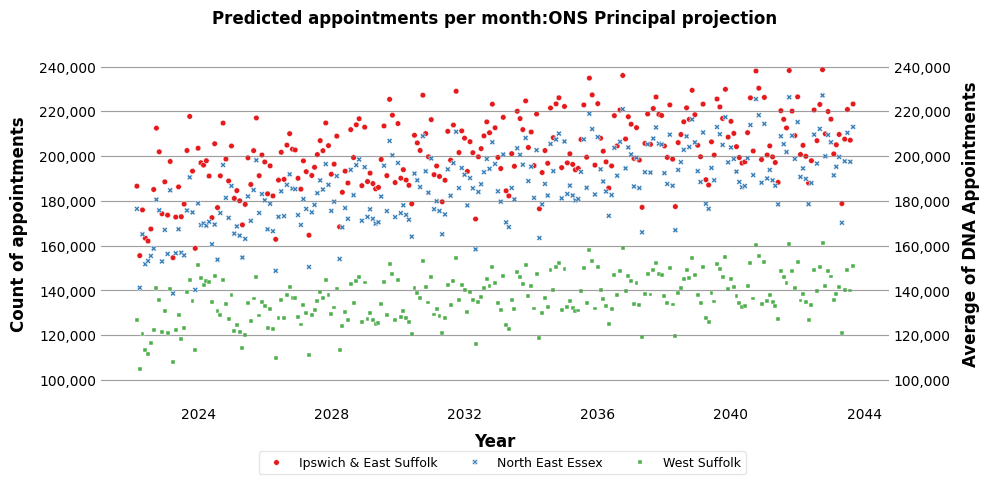

In [129]:
# Plotting attended vs dna for FY-2022-23-24
plt.subplots(figsize=(10,5))
plt.xlabel('Year')
plt.ylabel('Count of appointments')
plt.title('Predicted appointments per month:ONS Principal projection')
ax = sns.scatterplot(x='DATE', y='Predicted appointments per month (Principal projection)',  data=projections_combined_df, hue='Sub-ICB', style='Sub-ICB',palette='Set1', legend=False)
#ax.annotate('SNEE - ICB',xy=(38,550000), xytext=(36,900000), arrowprops =dict(arrowstyle='->',color='#231f20'),color='#231f20', fontsize=14)
#ax.legend(loc =(0.4,-1.4))

# Creating secondary y-axis
ax2 = ax.twinx()
ax2.set_ylabel('Average of DNA Appointments')
sns.scatterplot(x='DATE', y='COUNT_OF_APPOINTMENTS',  data=appointments_df, hue='Alliance', style='Alliance',palette='Set1')
ax2.legend(loc =(0.2,-0.2), ncol=3)

# Apply the comma-separated format to y-axis of both axes
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

# Set y-axis limits to start from 0 only
ax.set_ylim((90000,250000)) 
ax2.set_ylim((90000,250000))

plt.tight_layout()
plt.savefig(f"{plot_counter.plot_name}.png", dpi=300)

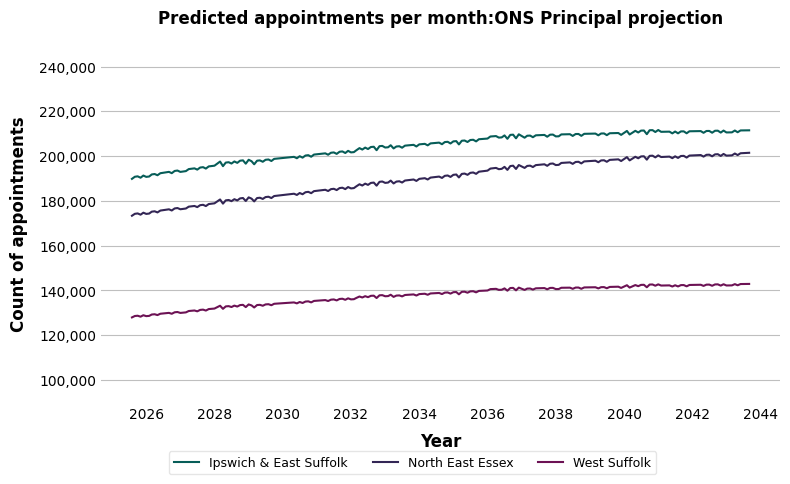

In [49]:
# Plotting the Principal projection
plt.subplots(figsize=(8,5))
sns.lineplot(x='DATE', y='Predicted appointments per month (Principal projection)',  data=smoothed_df, hue='Sub-ICB')
plt.xlabel('Year')
plt.ylabel('Count of appointments')
plt.title('Predicted appointments per month:ONS Principal projection')
plt.legend(loc=(0.1,-0.2), ncol=3)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.ylim(90000,250000)
plt.tight_layout()
plt.show()

#### 4.2.2. 10 year migration variant

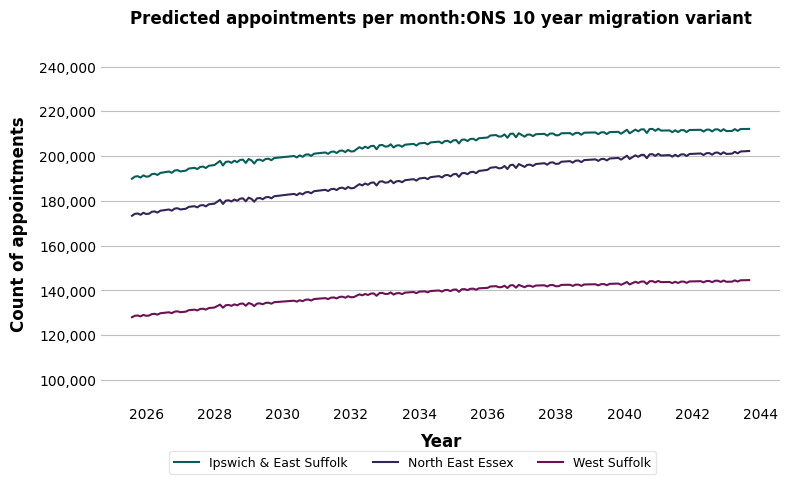

In [51]:
# Plotting the 10 year migration variant
plt.subplots(figsize=(8,5))
sns.lineplot(x='DATE', y='Predicted appointments per month (10 year migration variant)',  data=smoothed_df, hue='Sub-ICB')
plt.xlabel('Year')
plt.ylabel('Count of appointments')
plt.title('Predicted appointments per month:ONS 10 year migration variant')
plt.legend(loc=(0.1,-0.2), ncol=3)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.ylim(90000,250000)
plt.tight_layout()
plt.show()

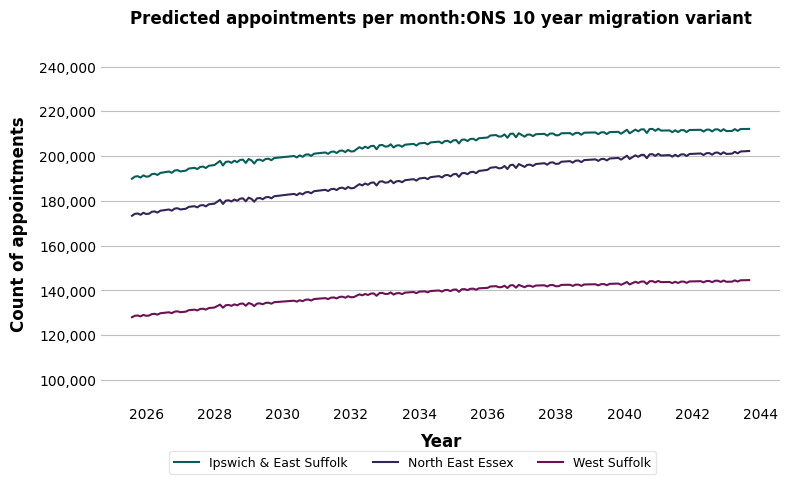

In [52]:
# Plotting the 10 year migration variant
plt.subplots(figsize=(8,5))
sns.lineplot(x='DATE', y='Predicted appointments per month (10 year migration variant)',  data=smoothed_df, hue='Sub-ICB')
plt.xlabel('Year')
plt.ylabel('Count of appointments')
plt.title('Predicted appointments per month:ONS 10 year migration variant')
plt.legend(loc=(0.1,-0.2), ncol=3)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.ylim(90000,250000)
plt.tight_layout()
plt.show()

#### 4.2.3. High international migration variant

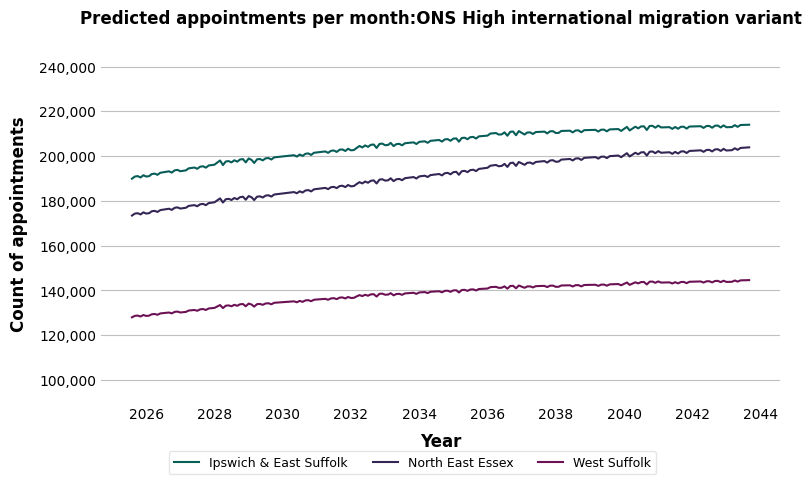

In [53]:
# Plotting the Principal projection
plt.subplots(figsize=(8,5))
sns.lineplot(x='DATE', y='Predicted appointments per month (High international migration variant)',  data=smoothed_df, hue='Sub-ICB')
plt.xlabel('Year')
plt.ylabel('Count of appointments')
plt.title('Predicted appointments per month:ONS High international migration variant')
plt.legend(loc=(0.1,-0.2), ncol=3)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.ylim(90000,250000)
plt.tight_layout()
plt.show()

#### 4.2.4. Low international migration variant

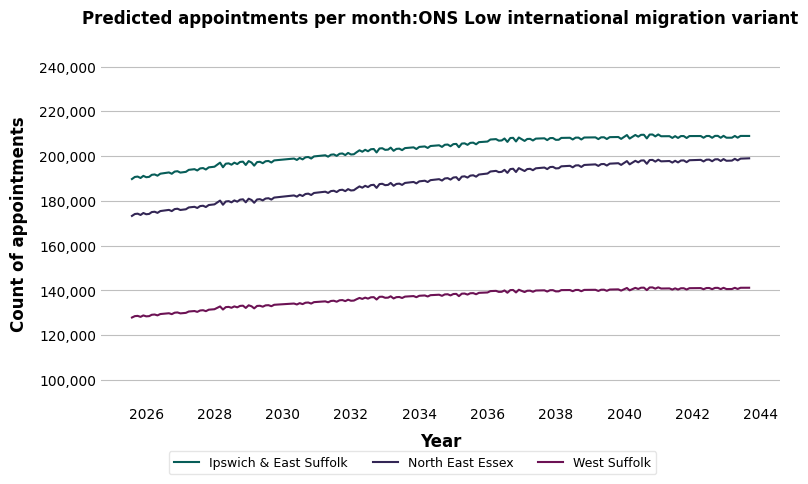

In [54]:
# Plotting the Principal projection
plt.subplots(figsize=(8,5))
sns.lineplot(x='DATE', y='Predicted appointments per month (Low international migration variant)',  data=smoothed_df, hue='Sub-ICB')
plt.xlabel('Year')
plt.ylabel('Count of appointments')
plt.title('Predicted appointments per month:ONS Low international migration variant')
plt.legend(loc=(0.1,-0.2), ncol=3)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.ylim(90000,250000)
plt.tight_layout()
plt.show()

#### 4.2.5. Alternative internal migration variant

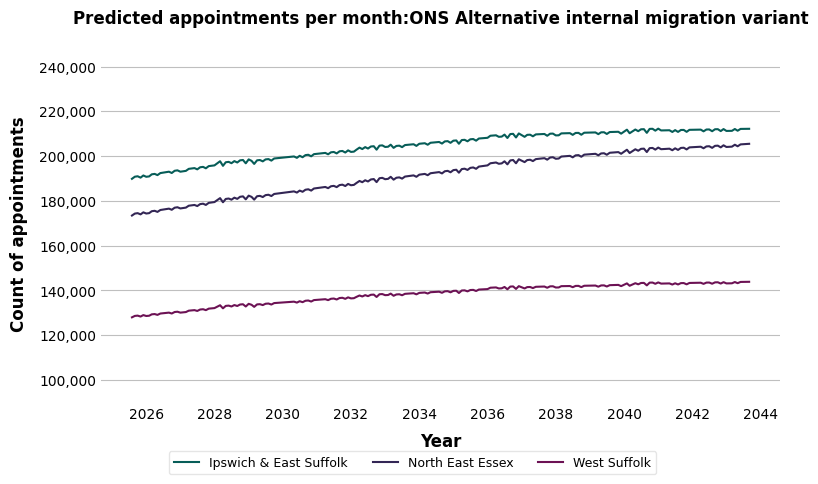

In [55]:
# Plotting the Principal projection
plt.subplots(figsize=(8,5))
sns.lineplot(x='DATE', y='Predicted appointments per month (Alternative internal migration variant)',  data=smoothed_df, hue='Sub-ICB')
plt.xlabel('Year')
plt.ylabel('Count of appointments')
plt.title('Predicted appointments per month:ONS Alternative internal migration variant')
plt.legend(loc=(0.1,-0.2), ncol=3)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.ylim(90000,250000)
plt.tight_layout()
plt.show()